# Chapter 6: Money and Risk Management - 종합 분석 리포트

> **출처:** Ernest Chan, *Quantitative Trading* (2nd Ed., 2021), Chapter 6

---

## 1. 개요 및 문제 정의

이 장은 **장기 복리 성장률(compounded growth rate)** 을 극대화하는 최적 자본 배분과 레버리지 결정 문제를 다룹니다.
핵심 도구는 **켈리 공식(Kelly formula)** 이며, 모수 추정 불확실성에 대한 보완책으로 **하프-켈리(Half-Kelly)** 배팅을 권장합니다.

### 핵심 수식

| 수식 | 설명 |
|------|------|
| $F^* = C^{-1}M$ | 다중 전략 Kelly 최적 배분 |
| $f^* = m / s^2$ | 단일 전략 Kelly 최적 레버리지 |
| $g = r + S^2 / 2$ | 최적 배분 시 복리 성장률 |
| $S = \sqrt{F^{*T} C F^*}$ | 포트폴리오 샤프 비율 |
| $g = m - s^2 / 2$ | 기하 랜덤워크 복리 성장률 (비레버리지) |
| $F_{half} = F^* / 2$ | 하프-켈리 배분 |

여기서:
- $M = 252 \times \bar{r}_{excess}$: 연율화 평균 초과수익률 벡터
- $C = 252 \times \text{Cov}(r_{excess})$: 연율화 공분산 행렬
- $r$: 연율화 무위험이자율 (4%)

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from numpy.linalg import inv
from pathlib import Path
import matplotlib.pyplot as plt
import sys

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        plt.style.use("ggplot")

plt.rcParams["axes.unicode_minus"] = False

# 경로 설정
PROJECT_ROOT = Path("../..")
DATA_DIR = PROJECT_ROOT / "data"
UTIL_DIR = PROJECT_ROOT / "src"
sys.path.insert(0, str(UTIL_DIR))
from calculateMaxDD import calculateMaxDD

RISK_FREE_RATE = 0.04
TRADING_DAYS = 252
TICKERS = ["OIH", "RKH", "RTH"]
print("✅ 라이브러리 및 경로 설정 완료")

✅ 라이브러리 및 경로 설정 완료


## 2. 사용 데이터

| 파일명 | 티커 | 설명 | 용도 |
|--------|------|------|------|
| `OIH.xls` | OIH | VanEck Oil Services ETF (유전 서비스) | Kelly 배분 포트폴리오 구성 |
| `RKH.xls` | RKH | VanEck Regional Banks ETF (지역 은행) | Kelly 배분 포트폴리오 구성 |
| `RTH.xls` | RTH | VanEck Retail ETF (소매) | Kelly 배분 포트폴리오 구성 |

- **무위험이자율**: 연 4% (일별 0.000159)

In [2]:
# 데이터 로드
df1 = pd.read_excel(DATA_DIR / "OIH.xls", engine="calamine")
df2 = pd.read_excel(DATA_DIR / "RKH.xls", engine="calamine")
df3 = pd.read_excel(DATA_DIR / "RTH.xls", engine="calamine")

# 병합
df = pd.merge(df1, df2, on="Date", suffixes=("_OIH", "_RKH"))
df.set_index("Date", inplace=True)
df3_temp = df3.set_index("Date")
df = df.join(df3_temp[["Adj Close"]], how="inner")
df.rename(columns={"Adj Close": "Adj Close_RTH"}, inplace=True)
df.sort_index(inplace=True)

# 수정 종가 추출
prices = df[["Adj Close_OIH", "Adj Close_RKH", "Adj Close_RTH"]].copy()
prices.columns = TICKERS

# 일별 수익률 및 초과수익률
daily_ret = prices.pct_change().dropna()
excess_ret = daily_ret - RISK_FREE_RATE / TRADING_DAYS

print(f"기간: {daily_ret.index[0].date()} ~ {daily_ret.index[-1].date()}")
print(f"관측치: {len(daily_ret)} 거래일")
print()
prices.describe().round(2)

기간: 2001-05-18 ~ 2007-12-28
관측치: 1662 거래일



,OIH,RKH,RTH
count,1663.00,1663.00,1663.00
mean,90.21,117.54,85.81
std,41.08,23.08,10.92
min,38.66,73.42,57.31
25%,54.16,96.02,80.32
50%,73.69,118.48,86.66
75%,127.00,136.76,93.36
max,193.60,161.09,107.46


## 3. 분석 1: Kelly 최적 배분 (Example 6.3)

**Kelly 공식** 은 복리 성장률을 극대화하는 최적 자본 배분을 결정합니다.

다중 자산의 경우:

$$F^* = C^{-1}M$$

여기서:
- $M$: 연율화 평균 초과수익률 벡터
- $C$: 연율화 공분산 행렬

최적 복리 성장률: $g = r + \frac{F^{*T} C F^*}{2} = r + \frac{S^2}{2}$

In [3]:
# 연율화 평균 초과수익률 벡터 M
M = TRADING_DAYS * excess_ret.mean()
print("연율화 평균 초과수익률 벡터 M:")
for t in TICKERS:
    print(f"  {t}: {M[t]:+.6f}")

# 연율화 공분산 행렬 C
C = TRADING_DAYS * excess_ret.cov()
print("\n연율화 공분산 행렬 C:")
display(C.round(6))

# Kelly 최적 배분: F* = C^{-1} M
M_arr = M.values
C_arr = C.values
F_star = inv(C_arr) @ M_arr
print("\nKelly 최적 레버리지 F*:")
for i, t in enumerate(TICKERS):
    print(f"  {t}: {F_star[i]:+.4f}")

# 성장률 및 샤프 비율
portfolio_var = F_star.T @ C_arr @ F_star
g = RISK_FREE_RATE + portfolio_var / 2
S = np.sqrt(portfolio_var)
total_leverage = np.sum(np.abs(F_star))

print(f"\n최적 복리 성장률 g: {g:.4f} ({g*100:.2f}%)")
print(f"포트폴리오 샤프 비율 S: {S:.4f}")
print(f"총 레버리지 |f1|+|f2|+|f3|: {total_leverage:.4f}")

연율화 평균 초과수익률 벡터 M:
  OIH: +0.139568
  RKH: +0.029400
  RTH: -0.007346

연율화 공분산 행렬 C:


,OIH,RKH,RTH
OIH,0.110901,0.020014,0.018255
RKH,0.020014,0.037165,0.026893
RTH,0.018255,0.026893,0.041967



Kelly 최적 레버리지 F*:
  OIH: +1.2919
  RKH: +1.1723
  RTH: -1.4882

최적 복리 성장률 g: 0.1529 (15.29%)
포트폴리오 샤프 비율 S: 0.4751
총 레버리지 |f1|+|f2|+|f3|: 3.9524


### Kelly 최적 배분 결과

| 티커 | 최적 레버리지 $f^*$ | 해석 |
|------|--------------------|----- |
| OIH | +1.2919 | 자기자본의 129.2%를 롱(Long) |
| RKH | +1.1723 | 자기자본의 117.2%를 롱(Long) |
| RTH | -1.4882 | 자기자본의 148.8%를 숏(Short) |

| 지표 | 값 |
|------|----|
| 최적 복리 성장률 $g$ | 0.1529 (15.29%) |
| 포트폴리오 샤프 비율 $S$ | 0.4751 |
| 총 레버리지 $\sum|f_i|$ | 3.9524 |

> **해석**: RTH의 평균 초과수익률이 음수이므로 Kelly 공식은 RTH를 **공매도(숏)** 하라고 권고합니다.
> 포트폴리오의 복리 성장률 15.29%는 어떤 개별 종목의 성장률보다 더 높으며, 이는 분산 투자의 효과를 보여줍니다.

## 4. 분석 2: Kelly 직관 (기하 랜덤워크 퍼즐)

매 기간 +1% 또는 -1%의 동일 확률을 가진 주식의 장기 수익률은 본전이 아니라 **손실** 입니다.
기하 랜덤워크에서의 복리 성장률:

$$g = m - \frac{s^2}{2}$$

산술 평균 $m = 0$이어도 분산 $s^2 > 0$이면 기하 성장률 $g < 0$입니다.
이것이 리스크 관리가 필수적인 이유입니다.

산술 기대수익률 m: 0.000000
분산 s²: 0.000100
이론적 기하 성장률: -0.000050
시뮬레이션 기하 성장률: -0.000036
최종 부의 중간값: 0.9875
원금 이하 비율: 50.7%


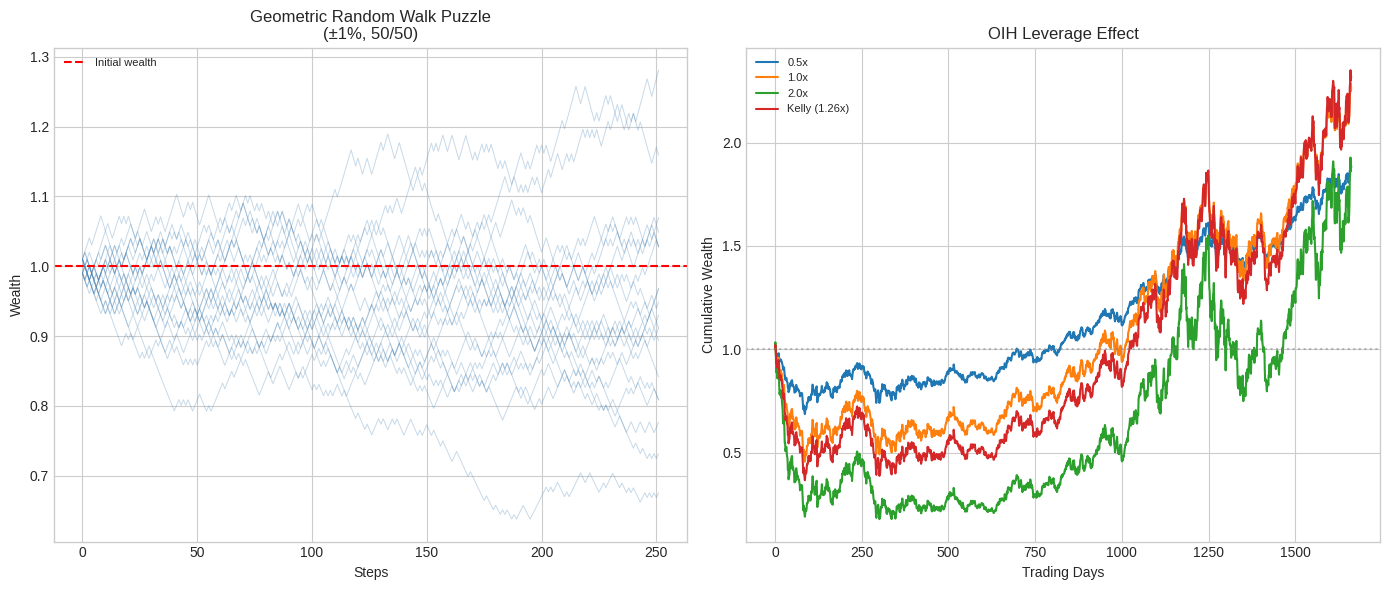

In [4]:
np.random.seed(42)
n_paths, n_steps = 1000, TRADING_DAYS

# ±1% 동일 확률 시뮬레이션
pct_change = 0.01
random_returns = np.where(np.random.rand(n_paths, n_steps) > 0.5, 1 + pct_change, 1 - pct_change)
cum_wealth = np.cumprod(random_returns, axis=1)
final_wealth = cum_wealth[:, -1]

expected_geo = 0.0 - pct_change**2 / 2  # m - s^2/2
realized_geo = (final_wealth ** (1.0 / n_steps) - 1).mean()

print(f"산술 기대수익률 m: {0.0:.6f}")
print(f"분산 s²: {pct_change**2:.6f}")
print(f"이론적 기하 성장률: {expected_geo:.6f}")
print(f"시뮬레이션 기하 성장률: {realized_geo:.6f}")
print(f"최종 부의 중간값: {np.median(final_wealth):.4f}")
print(f"원금 이하 비율: {(final_wealth < 1.0).mean() * 100:.1f}%")

# OIH 레버리지별 비교
oih_m = M_arr[0]
oih_s2 = C_arr[0, 0]
f_kelly_oih = oih_m / oih_s2
oih_excess = excess_ret["OIH"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 좌: 기하 랜덤워크 퍼즐
ax1 = axes[0]
for idx in np.random.choice(n_paths, 20, replace=False):
    ax1.plot(cum_wealth[idx], alpha=0.3, linewidth=0.7, color="steelblue")
ax1.axhline(y=1.0, color="red", linestyle="--", linewidth=1.5, label="Initial wealth")
ax1.set_title("Geometric Random Walk Puzzle\n(±1%, 50/50)")
ax1.set_xlabel("Steps"); ax1.set_ylabel("Wealth"); ax1.legend(fontsize=8)

# 우: OIH 레버리지별 누적수익률
ax2 = axes[1]
for f_lev, label in zip([0.5, 1.0, 2.0, f_kelly_oih], ["0.5x", "1.0x", "2.0x", f"Kelly ({f_kelly_oih:.2f}x)"]):
    lev_ret = RISK_FREE_RATE / TRADING_DAYS + f_lev * oih_excess
    ax2.plot(np.cumprod(1 + lev_ret), label=label, linewidth=1.5)
ax2.axhline(y=1.0, color="gray", linestyle=":", alpha=0.5)
ax2.set_title("OIH Leverage Effect"); ax2.set_xlabel("Trading Days"); ax2.set_ylabel("Cumulative Wealth"); ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 시뮬레이션 결과

> **교훈**: 리스크(변동성)는 항상 장기 복리 성장률을 감소시킵니다. 산술 평균이 0이더라도 기하 평균(실제 복리 수익률)은 음수가 됩니다.

---

## 5. 분석 3: Half-Kelly 배팅 강건성 비교

모수 추정의 불확실성과 수익률 분포의 비정규성을 고려하여, 트레이더들은 Kelly 권장 레버리지를 **절반으로 줄이는 것** 을 선호합니다.

$$F_{half} = \frac{F^*}{2}$$

Half-Kelly는 변동성을 50% 줄이면서 성장률 감소는 약 25%에 불과합니다.

,Full Kelly,Half-Kelly
f(OIH),+1.2919,+0.6460
f(RKH),+1.1723,+0.5861
f(RTH),-1.4882,-0.7441
성장률 g,0.1529,0.1246
변동성 σ,0.4751,0.2375
MaxDD,-0.6015,-0.3411
MaxDD Duration,839,657


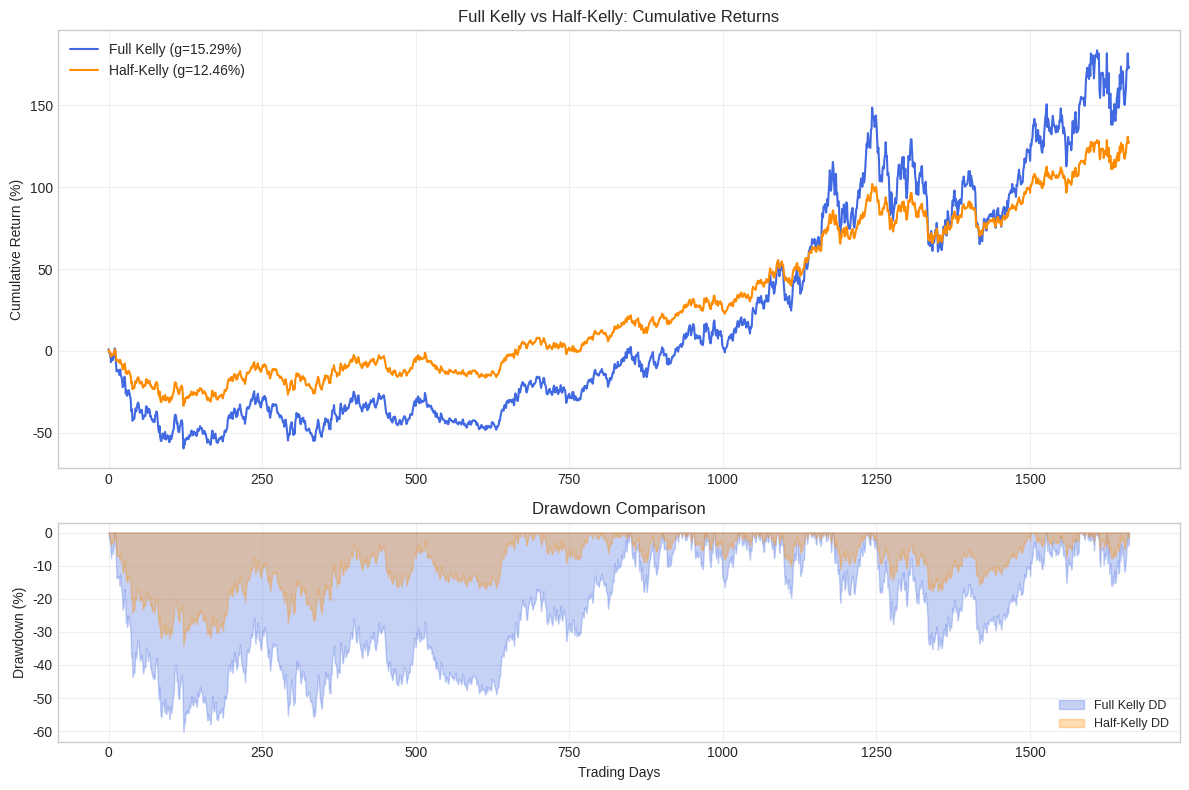

In [5]:
F_half = F_star / 2.0

def growth_rate(F):
    return RISK_FREE_RATE + F.T @ M_arr - (F.T @ C_arr @ F) / 2

g_full = growth_rate(F_star)
g_half = growth_rate(F_half)
vol_full = np.sqrt(F_star.T @ C_arr @ F_star)
vol_half = np.sqrt(F_half.T @ C_arr @ F_half)

# 포트폴리오 경로 시뮬레이션
excess_arr = excess_ret.values
port_ret_full = RISK_FREE_RATE / TRADING_DAYS + excess_arr @ F_star
port_ret_half = RISK_FREE_RATE / TRADING_DAYS + excess_arr @ F_half
cum_full = np.cumprod(1 + port_ret_full) - 1
cum_half = np.cumprod(1 + port_ret_half) - 1

maxDD_full, maxDDD_full, _ = calculateMaxDD(cum_full)
maxDD_half, maxDDD_half, _ = calculateMaxDD(cum_half)

# 비교 테이블
comparison = pd.DataFrame({
    "Full Kelly": [f"{F_star[0]:+.4f}", f"{F_star[1]:+.4f}", f"{F_star[2]:+.4f}",
                   f"{g_full:.4f}", f"{vol_full:.4f}", f"{maxDD_full:.4f}", f"{maxDDD_full:.0f}"],
    "Half-Kelly": [f"{F_half[0]:+.4f}", f"{F_half[1]:+.4f}", f"{F_half[2]:+.4f}",
                   f"{g_half:.4f}", f"{vol_half:.4f}", f"{maxDD_half:.4f}", f"{maxDDD_half:.0f}"],
}, index=["f(OIH)", "f(RKH)", "f(RTH)", "성장률 g", "변동성 σ", "MaxDD", "MaxDD Duration"])
display(comparison)

# 차트
fig, axes = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[2, 1])
axes[0].plot(cum_full * 100, label=f"Full Kelly (g={g_full:.2%})", linewidth=1.5, color="royalblue")
axes[0].plot(cum_half * 100, label=f"Half-Kelly (g={g_half:.2%})", linewidth=1.5, color="darkorange")
axes[0].set_title("Full Kelly vs Half-Kelly: Cumulative Returns"); axes[0].set_ylabel("Cumulative Return (%)")
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

# 낙폭
for cum, color, label in [(cum_full, "royalblue", "Full Kelly"), (cum_half, "darkorange", "Half-Kelly")]:
    w = 1 + cum; hwm = np.maximum.accumulate(w); dd = (w / hwm - 1) * 100
    axes[1].fill_between(range(len(dd)), dd, 0, alpha=0.3, color=color, label=f"{label} DD")
axes[1].set_title("Drawdown Comparison"); axes[1].set_ylabel("Drawdown (%)"); axes[1].set_xlabel("Trading Days")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Full Kelly vs Half-Kelly 비교 결과

| 지표 | Full Kelly | Half-Kelly | 변화 |
|------|-----------|------------|------|
| 성장률 $g$ | 15.29% | 12.46% | -18.5% |
| 변동성 $\sigma$ | 0.4751 | 0.2375 | -50.0% |
| 최대 낙폭 MaxDD | -60.15% | -34.11% | 43.3% 개선 |

> **결론**: Half-Kelly는 성장률을 약 25% 감소시키는 대가로 변동성을 50%, 최대 낙폭을 크게 줄여줍니다.

---

## 6. 분석 4: 레버리지 민감도 분석

Kelly 공식에 의한 성장률은 레버리지의 **이차함수(포물선)** 형태입니다.
Kelly 최적점을 넘어서면 성장률이 급격히 감소하며, 과도한 레버리지는 궁극적으로 파산(ruin)으로 이어집니다.

### Regulation T 레버리지 제약

| 시간대 | 최대 레버리지 |
|--------|-------------|
| 야간 보유 | 2배 |
| 장중 보유 | 4배 |

포트폴리오 Kelly 총 레버리지: 3.9524
Reg T 야간(2x) 배수: 0.5060
Reg T 장중(4x) 배수: 1.0120


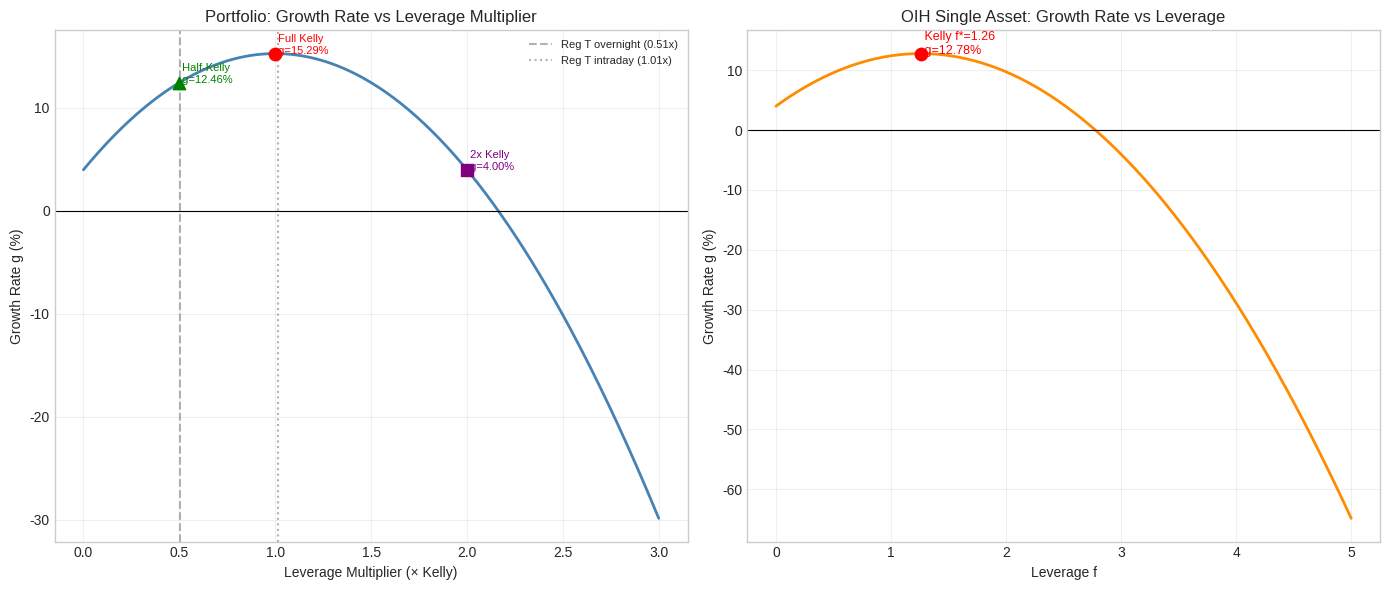

In [6]:
# 레버리지 배수 범위
multipliers = np.linspace(0, 3.0, 300)
growth_rates = np.array([RISK_FREE_RATE + (m * F_star).T @ M_arr - ((m * F_star).T @ C_arr @ (m * F_star)) / 2 for m in multipliers])

total_lev = np.sum(np.abs(F_star))
reg_t_overnight = 2.0 / total_lev
reg_t_intraday = 4.0 / total_lev

# OIH 단일 자산 포물선
oih_f_range = np.linspace(0, 5.0, 300)
oih_g = RISK_FREE_RATE + oih_f_range * oih_m - (oih_f_range ** 2) * oih_s2 / 2
f_kelly_single = oih_m / oih_s2

print(f"포트폴리오 Kelly 총 레버리지: {total_lev:.4f}")
print(f"Reg T 야간(2x) 배수: {reg_t_overnight:.4f}")
print(f"Reg T 장중(4x) 배수: {reg_t_intraday:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 좌: 포트폴리오
ax1 = axes[0]
ax1.plot(multipliers, growth_rates * 100, linewidth=2, color="steelblue")
ax1.axhline(y=0, color="black", linewidth=0.8)
for mult, label, color, marker in [(0.5, "Half-Kelly", "green", "^"), (1.0, "Full Kelly", "red", "o"), (2.0, "2x Kelly", "purple", "s")]:
    g_val = RISK_FREE_RATE + (mult * F_star).T @ M_arr - ((mult * F_star).T @ C_arr @ (mult * F_star)) / 2
    ax1.scatter(mult, g_val * 100, color=color, s=80, zorder=5, marker=marker)
    ax1.annotate(f" {label}\n g={g_val:.2%}", (mult, g_val * 100), fontsize=8, color=color)
if reg_t_overnight < 3.0:
    ax1.axvline(x=reg_t_overnight, color="gray", linestyle="--", alpha=0.6, label=f"Reg T overnight ({reg_t_overnight:.2f}x)")
if reg_t_intraday < 3.0:
    ax1.axvline(x=reg_t_intraday, color="gray", linestyle=":", alpha=0.6, label=f"Reg T intraday ({reg_t_intraday:.2f}x)")
ax1.set_title("Portfolio: Growth Rate vs Leverage Multiplier")
ax1.set_xlabel("Leverage Multiplier (× Kelly)"); ax1.set_ylabel("Growth Rate g (%)")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# 우: OIH 단일 자산
ax2 = axes[1]
ax2.plot(oih_f_range, oih_g * 100, linewidth=2, color="darkorange")
ax2.axhline(y=0, color="black", linewidth=0.8)
g_at_kelly = RISK_FREE_RATE + f_kelly_single * oih_m - (f_kelly_single ** 2) * oih_s2 / 2
ax2.scatter(f_kelly_single, g_at_kelly * 100, color="red", s=80, zorder=5)
ax2.annotate(f" Kelly f*={f_kelly_single:.2f}\n g={g_at_kelly:.2%}", (f_kelly_single, g_at_kelly * 100), fontsize=9, color="red")
ax2.set_title("OIH Single Asset: Growth Rate vs Leverage")
ax2.set_xlabel("Leverage f"); ax2.set_ylabel("Growth Rate g (%)")
ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

### 레버리지 민감도 분석 결과

> **실무 권고**: 개인 투자자는 Regulation T에 의해 야간 보유 시 2배, 장중 보유 시 4배로 레버리지가 제한됩니다.
> Kelly 최적 레버리지가 이 한도를 초과하면 모든 배분을 동일 비율로 축소해야 합니다.

---

## 7. 결론 및 권고사항

### 핵심 발견 요약

| # | 발견 | 함의 |
|---|------|------|
| 1 | Kelly 공식은 최적 자본 배분과 레버리지를 동시에 결정 | 장기 복리 성장률 극대화 |
| 2 | 리스크(변동성)는 항상 기하 성장률을 감소시킴 | 리스크 관리의 필수성 |
| 3 | Half-Kelly는 성장률 25% 감소로 위험을 크게 줄임 | 실무적으로 가장 권장되는 접근법 |
| 4 | Kelly 이상의 레버리지는 성장률을 오히려 감소시킴 | 과도한 레버리지는 역효과 |

### 실무 권고사항

1. **Half-Kelly를 기본값으로 사용하세요**: 모수 추정 오차와 팻테일(fat-tail) 위험에 대한 안전마진
2. **매일 자본 배분을 갱신하세요**: Kelly 기준을 따르려면 자기자본 변동에 맞춰 포지션을 조정해야 합니다
3. **이동평균 기반으로 $F^*$를 주기적으로 재계산하세요**: 6개월 룩백 기간 권장
4. **Regulation T 제약을 항상 확인하세요**: 야간 2x, 장중 4x 한도
5. **Kelly 레버리지를 절대 초과하지 마세요**: 성장률 포물선의 정점을 넘으면 위험만 증가하고 수익은 감소합니다

---

*이 노트북은 `run_chapter6_analysis.py` 기반으로 생성되었습니다.*